# EDA - Campeonato Brasileiro (2003–2025)

Este notebook carrega as 4 bases do projeto, faz a limpeza básica, e conduz a análise exploratória de dados (EDA) que fundamenta as próximas etapas.

## 1. Setup e carga dos dados

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


COLORS = ["#1f6f5c", "#c0553a", "#3b6ea5", "#c9a227", "#7a5195"]

DATA_DIR = "../datasets"

full = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-full.csv")
gols = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-gols.csv")
cartoes = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-cartoes.csv")
est = pd.read_csv(f"{DATA_DIR}/campeonato-brasileiro-estatisticas-full.csv")

for name, df in [("full", full), ("gols", gols), ("cartoes", cartoes), ("estatisticas", est)]:
    print(f"{name}: {df.shape[0]} linhas, {df.shape[1]} colunas")

full: 9165 linhas, 17 colunas
gols: 10820 linhas, 6 colunas
cartoes: 20953 linhas, 8 colunas
estatisticas: 18330 linhas, 13 colunas


## 2. Limpeza e engenharia de variáveis

- Converte data para datetime e extrair o ano (temporada).
- Cria a variável resultado (Vitória Mandante / Empate / Vitória Visitante).
- Cria total_gols e saldo_mandante.
- Converte posse_de_bola (string com %) para float.

In [22]:
full["data"] = pd.to_datetime(full["data"], dayfirst=True)
full["ano"] = full["data"].dt.year

def classifica_resultado(row):
    if row["vencedor"] == "-":
        return "Empate"
    elif row["vencedor"] == row["mandante"]:
        return "Vitória Mandante"
    else:
        return "Vitória Visitante"

full["resultado"] = full.apply(classifica_resultado, axis=1)
full["total_gols"] = full["mandante_Placar"] + full["visitante_Placar"]
full["saldo_mandante"] = full["mandante_Placar"] - full["visitante_Placar"]

est["posse_de_bola"] = (
    est["posse_de_bola"].astype(str).str.replace("%", "", regex=False)
    .replace("nan", np.nan).astype(float)
)

full.head()

,ID,rodata,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,...,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao,ano,resultado,total_gols,saldo_mandante
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,...,Brinco de Ouro,4,2,SP,RJ,NaN,2003,Vitória Mandante,6,2
1,2,1,2003-03-29,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,...,Arena da Baixada,2,0,PR,RS,NaN,2003,Vitória Mandante,2,2
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,...,Maracanã,1,1,RJ,PR,NaN,2003,Empate,2,0
3,4,1,2003-03-30,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,...,Serra Dourada,2,2,GO,PA,NaN,2003,Empate,4,0
4,5,1,2003-03-30,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,...,Beira Rio,1,1,RS,SP,NaN,2003,Empate,2,0


## 3. Verificação e análise dos dados faltantes


In [23]:
for name, df in [("full", full), ("gols", gols), ("cartoes", cartoes), ("estatisticas", est)]:
    miss = df.isna().mean().mul(100).round(1)
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{name} ({len(df)} linhas):")
    print(miss if len(miss) else "  (sem valores faltantes)")


full (9165 linhas):
arrecadacao           95.9
formacao_mandante     54.3
formacao_visitante    54.3
tecnico_mandante      50.3
tecnico_visitante     50.3
dtype: float64

gols (10820 linhas):
tipo_de_gol    88.0
dtype: float64

cartoes (20953 linhas):
posicao       5.7
num_camisa    1.8
dtype: float64

estatisticas (18330 linhas):
precisao_passes    71.3
posse_de_bola      58.7
dtype: float64


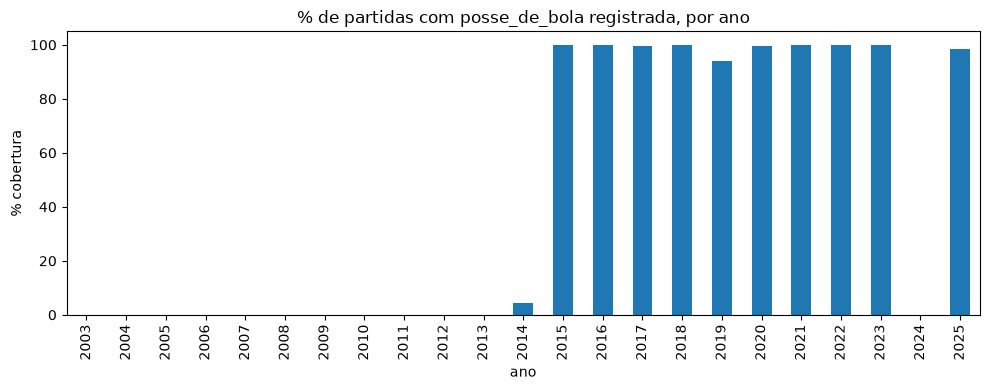

In [24]:
# posse_de_bola faltante por ano -- checar se há um recorte temporal confiável
est_ano = est.merge(full[["ID", "ano"]], left_on="partida_id", right_on="ID")
cobertura = est_ano.groupby("ano")["posse_de_bola"].apply(lambda s: 100 - s.isna().mean() * 100).round(1)
cobertura.plot(kind="bar", figsize=(10, 4), title="% de partidas com posse_de_bola registrada, por ano")
plt.ylabel("% cobertura")
plt.tight_layout()
plt.savefig("../figuras/porcentagem_posse_de_bola")
plt.show()

**IMPORTANTE**: posse_de_bola só tem cobertura entre 2015 e 2023. Qualquer análise que use estatísticas de jogo (posse, chutes, passes) deve restringir o recorte temporal a esse período para evitar viés de seleção.

## 4. Relevancia do mando de campo

resultado
Vitória Mandante     49.6
Empate               26.4
Vitória Visitante    23.9
Name: count, dtype: float64


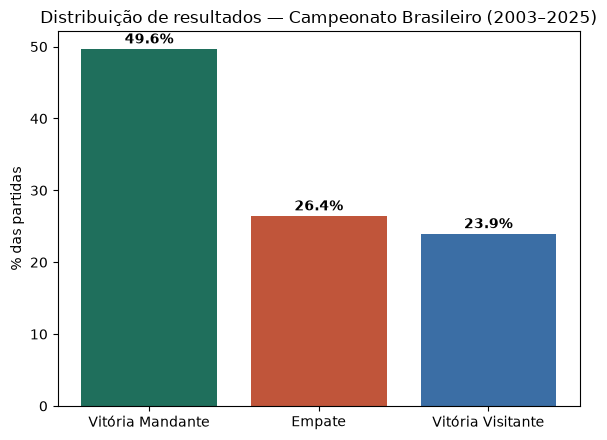

In [25]:
contagem = full["resultado"].value_counts()[["Vitória Mandante", "Empate", "Vitória Visitante"]]
pct = contagem / contagem.sum() * 100
print(pct.round(1))

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(contagem.index, pct.values, color=COLORS[:3])
for b, p in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8, f"{p:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("% das partidas")
ax.set_title("Distribuição de resultados — Campeonato Brasileiro (2003–2025)")
plt.tight_layout()
plt.savefig("../figuras/distribuicao_de_resultados")
plt.show()

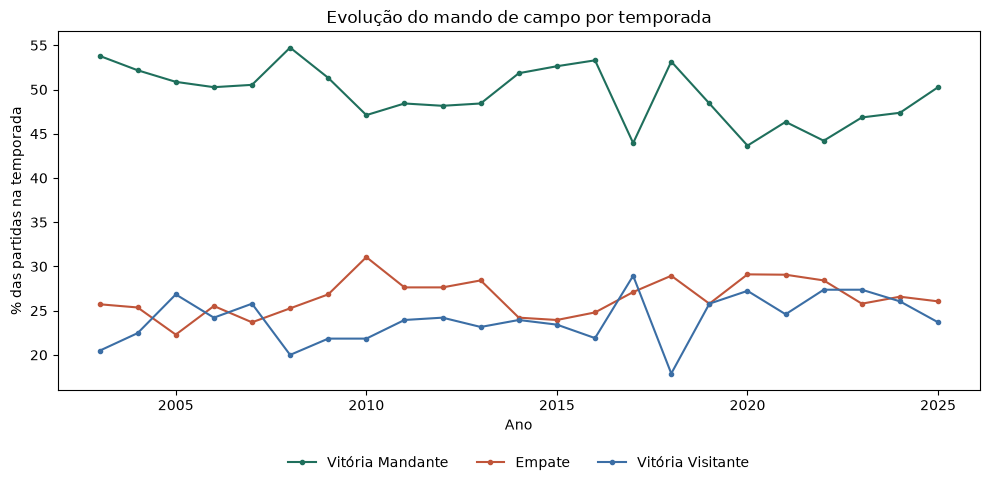

In [26]:
res_ano = full.groupby(["ano", "resultado"]).size().unstack(fill_value=0)
res_ano_pct = res_ano.div(res_ano.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
for col, c in zip(["Vitória Mandante", "Empate", "Vitória Visitante"], COLORS[:3]):
    ax.plot(res_ano_pct.index, res_ano_pct[col], marker="o", ms=3, label=col, color=c)
ax.set_ylabel("% das partidas na temporada")
ax.set_xlabel("Ano")
ax.set_title("Evolução do mando de campo por temporada")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.savefig("../figuras/mando_ao_longo_do_tempo")
plt.show()

## 5. Gols por partida

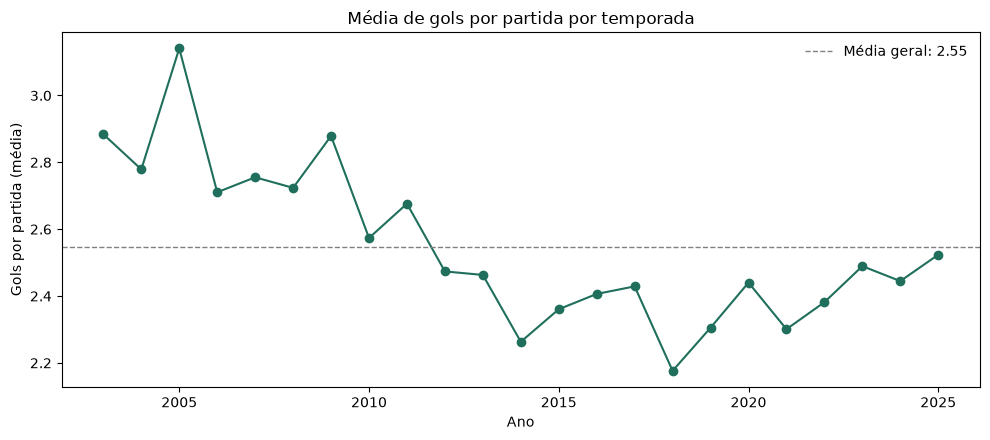

In [27]:
gols_ano = full.groupby("ano")["total_gols"].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(gols_ano.index, gols_ano.values, marker="o", color=COLORS[0])
ax.axhline(gols_ano.mean(), ls="--", color="gray", lw=1, label=f"Média geral: {gols_ano.mean():.2f}")
ax.set_ylabel("Gols por partida (média)")
ax.set_xlabel("Ano")
ax.set_title("Média de gols por partida por temporada")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../figuras/media_gols_partida_temporada")
plt.show()

## Frequencia de placares

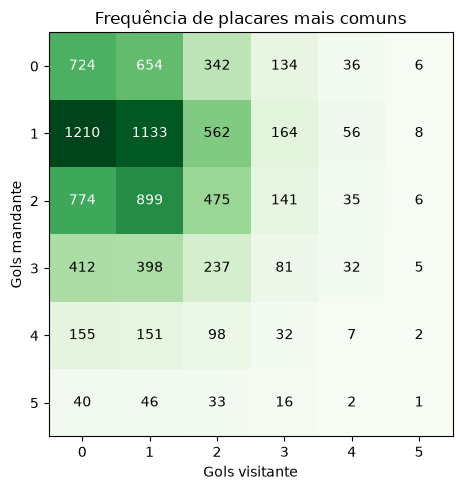

In [28]:
placar = full.groupby(["mandante_Placar", "visitante_Placar"]).size().unstack(fill_value=0).iloc[:6, :6]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(placar.values, cmap="Greens")
ax.set_xticks(range(len(placar.columns))); ax.set_xticklabels(placar.columns)
ax.set_yticks(range(len(placar.index))); ax.set_yticklabels(placar.index)
for i in range(len(placar.index)):
    for j in range(len(placar.columns)):
        v = placar.values[i, j]
        ax.text(j, i, v, ha="center", va="center",
                color="white" if v > placar.values.max() * 0.5 else "black")
ax.set_xlabel("Gols visitante"); ax.set_ylabel("Gols mandante")
ax.set_title("Frequência de placares mais comuns")
plt.tight_layout()
plt.savefig("../figuras/placares_comuns")
plt.show()

## 6. Estatísticas de jogo: mandante vs. visitante

cartao     Amarelo  Vermelho
condicao                    
Mandante      9411       463
Visitante    10456       623


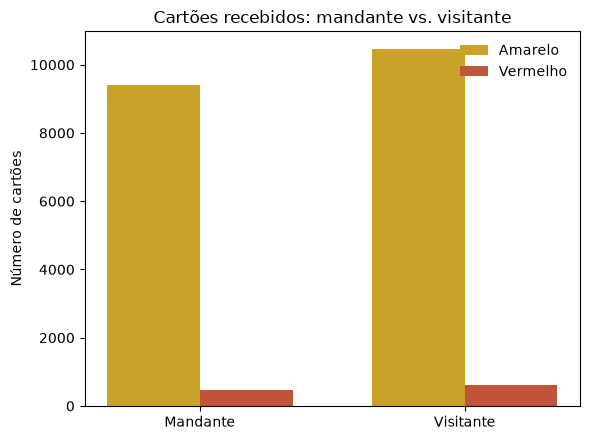

In [29]:
cart_join = cartoes.merge(full[["ID", "mandante", "visitante"]], left_on="partida_id", right_on="ID")
cart_join["condicao"] = np.where(
    cart_join["clube"] == cart_join["mandante"], "Mandante",
    np.where(cart_join["clube"] == cart_join["visitante"], "Visitante", "Outro")
)
cart_tab = cart_join.groupby(["condicao", "cartao"]).size().unstack(fill_value=0).loc[["Mandante", "Visitante"]]
print(cart_tab)

fig, ax = plt.subplots(figsize=(6, 4.5))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, cart_tab["Amarelo"], width=w, label="Amarelo", color=COLORS[3])
ax.bar(x + w/2, cart_tab["Vermelho"], width=w, label="Vermelho", color=COLORS[1])
ax.set_xticks(x); ax.set_xticklabels(cart_tab.index)
ax.set_ylabel("Número de cartões")
ax.set_title("Cartões recebidos: mandante vs. visitante")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../figuras/cartoes_mandante_visitante")
plt.show()

           chutes  chutes_no_alvo  passes  faltas  escanteios  posse_de_bola
condicao                                                                    
Mandante     6.00            1.62  177.31    6.12        2.45          51.64
Visitante    4.58            1.22  167.55    6.10        1.87          48.36


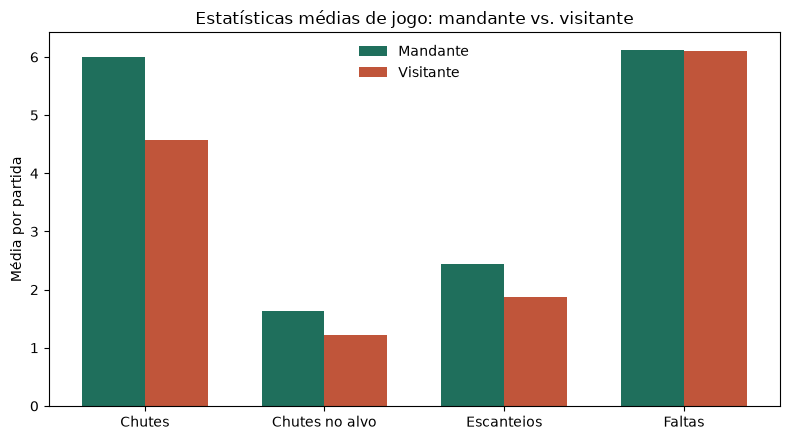

In [30]:
est_join = est.merge(full[["ID", "mandante", "visitante", "ano"]], left_on="partida_id", right_on="ID")
est_join["condicao"] = np.where(
    est_join["clube"] == est_join["mandante"], "Mandante",
    np.where(est_join["clube"] == est_join["visitante"], "Visitante", "Outro")
)
stats_cond = est_join[est_join["condicao"].isin(["Mandante", "Visitante"])].groupby("condicao")[
    ["chutes", "chutes_no_alvo", "passes", "faltas", "escanteios", "posse_de_bola"]
].mean()
print(stats_cond.round(2))

metrics = ["chutes", "chutes_no_alvo", "escanteios", "faltas"]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, stats_cond.loc["Mandante", metrics], width=w, label="Mandante", color=COLORS[0])
ax.bar(x + w/2, stats_cond.loc["Visitante", metrics], width=w, label="Visitante", color=COLORS[1])
ax.set_xticks(x); ax.set_xticklabels(["Chutes", "Chutes no alvo", "Escanteios", "Faltas"])
ax.set_ylabel("Média por partida")
ax.set_title("Estatísticas médias de jogo: mandante vs. visitante")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("../figuras/estatisticas_mandante_visitante")
plt.show()

## 7. Clubes com mais vitórias em casa

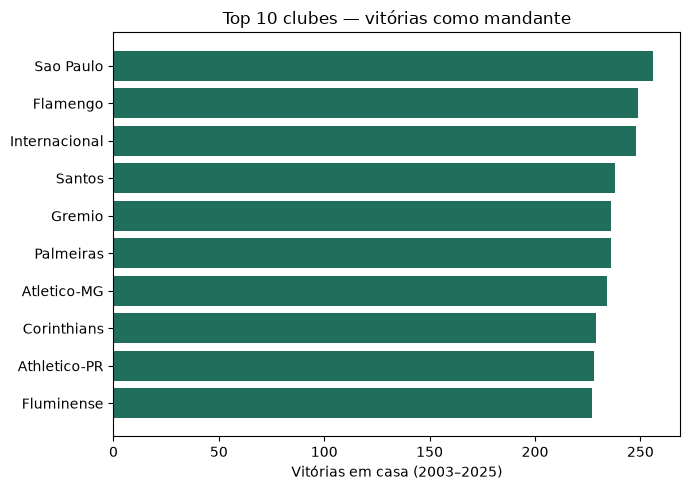

In [31]:
vit_mandante = full[full["vencedor"] == full["mandante"]]["mandante"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(vit_mandante.index[::-1], vit_mandante.values[::-1], color=COLORS[0])
ax.set_xlabel("Vitórias em casa (2003–2025)")
ax.set_title("Top 10 clubes — vitórias como mandante")
plt.tight_layout()
plt.savefig("../figuras/top10_vitorias_mandante")
plt.show()

## 8. Síntese

- O mandante vence 50% das partidas contra 24% do visitante, com vantagem consistente ao longo de 23 temporadas.
- O mandante domina métricas de volume ofensivo (posse, chutes, chutes no alvo, escanteios) e recebe menos cartões.
- `posse_de_bola` só é confiável em 2015–2023.



# 9.1 Construção do dataset tratado

Regras de tratamento aplicadas:
1. **Colunas de baixa utilidade/alta ausência** (`arrecadacao`, `formacao_mandante/visitante`, `tecnico_mandante/visitante`) são descartadas do dataset tratado, ficando disponíveis no CSV bruto para quem quiser explorá-las, mas não entram aqui por terem >50% de valores faltantes.
2. Descarta as colunas arrecadacao, formacao_mandante/visitante, tecnico_mandante/visitante devido a baixa utilidade e alta ausencia de informacoes.
3. **Zeros estruturais viram `NaN`**: para `chutes`, `chutes_no_alvo`, `passes`, `faltas`, `cartao_amarelo`, `cartao_vermelho`, `impedimentos` e `escanteios` da tabela `estatisticas`, os anos sem coleta real (2003–2014 e 2024) são marcados como ausentes em vez de zero.
4. Estatísticas de jogo e cartões são pivotadas para o nível de partida (uma coluna por métrica × mandante/visitante), em vez de uma linha por time.
5. Gols são agregados por partida e por time, com contagem de pênaltis e gols contra.

In [12]:
# 9.1 Base da partida: colunas relevantes + variáveis já criadas na Seção 2
colunas_base = [
    "ID", "data", "ano", "rodata", "mandante", "visitante",
    "mandante_Placar", "visitante_Placar", "resultado", "total_gols", "saldo_mandante",
    "vencedor", "arena", "mandante_Estado", "visitante_Estado"
]
tratado = full[colunas_base].rename(columns={
    "ID": "partida_id", "mandante_Placar": "gols_mandante", "visitante_Placar": "gols_visitante"
}).copy()

tratado.shape

(9165, 15)

In [ ]:
# Gols por time e por tipo (pênalti / gol contra), agregados por partida
gols_time = gols.merge(full[["ID", "mandante", "visitante"]], left_on="partida_id", right_on="ID")
gols_time["condicao"] = np.where(gols_time["clube"] == gols_time["mandante"], "mandante",
                           np.where(gols_time["clube"] == gols_time["visitante"], "visitante", "outro"))

agg_gols = gols_time.groupby(["partida_id", "condicao"]).agg(
    gols_penalti=("tipo_de_gol", lambda s: (s == "Penalty").sum()),
    gols_contra=("tipo_de_gol", lambda s: (s == "Gol Contra").sum())
).unstack("condicao")
agg_gols.columns = [f"{col}_{cond}" for col, cond in agg_gols.columns]
agg_gols = agg_gols.reset_index()

tratado = tratado.merge(agg_gols, on="partida_id", how="left")
for c in [c for c in tratado.columns if c.startswith("gols_penalti") or c.startswith("gols_contra")]:
    tratado[c] = tratado[c].fillna(0).astype(int)

tratado.filter(like="gols_").head()

,gols_mandante,gols_visitante,gols_penalti_mandante,gols_penalti_visitante,gols_contra_mandante,gols_contra_visitante
0,4,2,0,0,0,0
1,2,0,0,0,0,0
2,1,1,0,0,0,0
3,2,2,0,0,0,0
4,1,1,0,0,0,0


In [ ]:
# Cartões por time, pivotados para o nível de partida
cartoes_time = cartoes.merge(full[["ID", "mandante", "visitante"]], left_on="partida_id", right_on="ID")
cartoes_time["condicao"] = np.where(cartoes_time["clube"] == cartoes_time["mandante"], "mandante",
                              np.where(cartoes_time["clube"] == cartoes_time["visitante"], "visitante", "outro"))

agg_cartoes = cartoes_time.groupby(["partida_id", "condicao", "cartao"]).size().unstack("cartao", fill_value=0)
agg_cartoes = agg_cartoes.unstack("condicao")
agg_cartoes.columns = [f"cartao_{cor.lower()}_{cond}" for cor, cond in agg_cartoes.columns]
agg_cartoes = agg_cartoes.reset_index()

tratado = tratado.merge(agg_cartoes, on="partida_id", how="left")
colunas_cartao = [c for c in tratado.columns if c.startswith("cartao_")]
tratado[colunas_cartao] = tratado[colunas_cartao].fillna(0).astype(int)

tratado.filter(like="cartao_").head()

,cartao_amarelo_mandante,cartao_amarelo_visitante,cartao_vermelho_mandante,cartao_vermelho_visitante
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0


In [ ]:
# Estatísticas de jogo: corrigir zeros estruturais -> NaN, depois pivotar para o nível de partida
anos_sem_estatisticas = list(range(2003, 2015)) + [2024]

colunas_estatisticas = ["chutes", "chutes_no_alvo", "passes", "faltas",
                         "impedimentos", "escanteios", "posse_de_bola"]

est_corrigido = est.merge(full[["ID", "mandante", "visitante", "ano"]], left_on="partida_id", right_on="ID").copy()
mascara_invalida = est_corrigido["ano"].isin(anos_sem_estatisticas)
for c in colunas_estatisticas:
    est_corrigido.loc[mascara_invalida, c] = np.nan

est_corrigido["condicao"] = np.where(est_corrigido["clube"] == est_corrigido["mandante"], "mandante",
                               np.where(est_corrigido["clube"] == est_corrigido["visitante"], "visitante", "outro"))

agg_stats = est_corrigido.pivot_table(index="partida_id", columns="condicao", values=colunas_estatisticas)
agg_stats.columns = [f"{metrica}_{cond}" for metrica, cond in agg_stats.columns]
agg_stats = agg_stats.reset_index()

tratado = tratado.merge(agg_stats, on="partida_id", how="left")
tratado.filter(like="chutes").head()

,chutes_mandante,chutes_visitante,chutes_no_alvo_mandante,chutes_no_alvo_visitante
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN


## 9.2 Checagem de qualidade do dataset tratado

In [16]:
print(f"Formato final: {tratado.shape[0]} partidas x {tratado.shape[1]} colunas\n")

faltantes = tratado.isna().mean().mul(100).round(1)
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
print("Colunas com valores faltantes (% do total):")
print(faltantes)

Formato final: 9165 partidas x 37 colunas

Colunas com valores faltantes (% do total):
posse_de_bola_visitante     58.9
posse_de_bola_mandante      58.9
chutes_no_alvo_mandante     58.5
chutes_no_alvo_visitante    58.5
chutes_mandante             58.5
chutes_visitante            58.5
escanteios_visitante        58.5
escanteios_mandante         58.5
faltas_mandante             58.5
faltas_visitante            58.5
impedimentos_visitante      58.5
impedimentos_mandante       58.5
passes_visitante            58.5
passes_mandante             58.5
dtype: float64


## 9.3 Exportação

In [32]:
caminho_saida = "../datasets/campeonato_brasileiro_tratado.csv"
tratado.to_csv(caminho_saida, index=False)

print(f"Dataset tratado salvo em: {caminho_saida}")
print(f"{tratado.shape[0]} linhas x {tratado.shape[1]} colunas")
tratado.head()

Dataset tratado salvo em: ../datasets/campeonato_brasileiro_tratado.csv
9165 linhas x 37 colunas


,partida_id,data,ano,rodata,mandante,visitante,gols_mandante,gols_visitante,resultado,total_gols,...,escanteios_mandante,escanteios_visitante,faltas_mandante,faltas_visitante,impedimentos_mandante,impedimentos_visitante,passes_mandante,passes_visitante,posse_de_bola_mandante,posse_de_bola_visitante
0,1,2003-03-29,2003,1,Guarani,Vasco,4,2,Vitória Mandante,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2003-03-29,2003,1,Athletico-PR,Gremio,2,0,Vitória Mandante,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2003-03-30,2003,1,Flamengo,Coritiba,1,1,Empate,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2003-03-30,2003,1,Goias,Paysandu,2,2,Empate,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2003-03-30,2003,1,Internacional,Ponte Preta,1,1,Empate,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
